In [24]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Statistical analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson


In [25]:
train = pd.read_csv("../Data/train.csv")
test = pd.read_csv("../Data/test.csv")

In [26]:
categories = [25, 35, 45, 60, 70]
train['speed_limit_cat'] = pd.Categorical(train['speed_limit'], categories=categories, ordered=True)
test['speed_limit_cat'] = pd.Categorical(test['speed_limit'], categories=categories, ordered=True)

In [27]:
train = train.drop(columns = ['speed_limit'])
test = test.drop(columns = ['speed_limit'])

In [28]:
train.head()

,id,road_type,num_lanes,curvature,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,speed_limit_cat
0,0,urban,2,0.06,daylight,rainy,False,True,afternoon,False,True,1,0.13,35
1,1,urban,4,0.99,daylight,clear,True,False,evening,True,True,0,0.35,35
2,2,rural,4,0.63,dim,clear,False,True,morning,True,False,2,0.30,70
3,3,highway,4,0.07,dim,rainy,True,True,morning,False,False,1,0.21,35
4,4,rural,1,0.58,daylight,foggy,False,False,evening,True,False,1,0.56,60


In [29]:
test.head()

,id,road_type,num_lanes,curvature,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,speed_limit_cat
0,517754,highway,2,0.34,night,clear,True,True,afternoon,True,True,1,45
1,517755,urban,3,0.04,dim,foggy,True,False,afternoon,True,False,0,45
2,517756,urban,2,0.59,dim,clear,True,False,afternoon,True,True,1,35
3,517757,rural,4,0.95,daylight,rainy,False,False,afternoon,False,False,2,35
4,517758,highway,2,0.86,daylight,clear,True,False,evening,False,True,3,35


In [30]:
# Drop ID column
X = train.drop(columns=['id', 'accident_risk'])
y = train['accident_risk']

# Convert boolean features to 0/1
boolean_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
X[boolean_features] = X[boolean_features].astype(int)

# One-hot encode categorical variables
categorical_features = ['road_type', 'lighting', 'weather', 'time_of_day', 'speed_limit_cat']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Convert any remaining bools to int
X = X.astype({col: 'int' for col in X.columns if X[col].dtype == 'bool'})

# Add constant for intercept
X = sm.add_constant(X)

In [31]:
X.head()

,const,num_lanes,curvature,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,speed_limit_cat_35,speed_limit_cat_45,speed_limit_cat_60,speed_limit_cat_70
0,1.0,2,0.06,0,1,0,1,1,0,1,0,0,0,1,0,0,1,0,0,0
1,1.0,4,0.99,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,0
2,1.0,4,0.63,0,1,1,0,2,1,0,1,0,0,0,0,1,0,0,0,1
3,1.0,4,0.07,1,1,0,0,1,0,0,1,0,0,1,0,1,1,0,0,0
4,1.0,1,0.58,0,0,1,0,1,1,0,0,0,1,0,1,0,0,0,1,0


In [32]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numeric features
numeric_features = ['num_lanes', 'curvature', 'num_reported_accidents']
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])


# Fit model on training subset
model = sm.OLS(y_train, X_train).fit()

# Print full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                 1.393e+05
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:15:37   Log-Likelihood:             5.6916e+05
No. Observations:              414203   AIC:                        -1.138e+06
Df Residuals:                  414183   BIC:                        -1.138e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

### Check Linear Regression Assumptions

### 1. Residuals

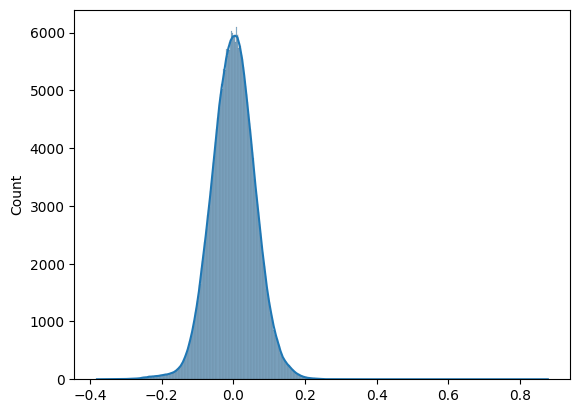

In [33]:
# Residuals
residuals = model.resid

# 1️⃣ Residual histogram
sns.histplot(residuals, kde=True)
plt.show()

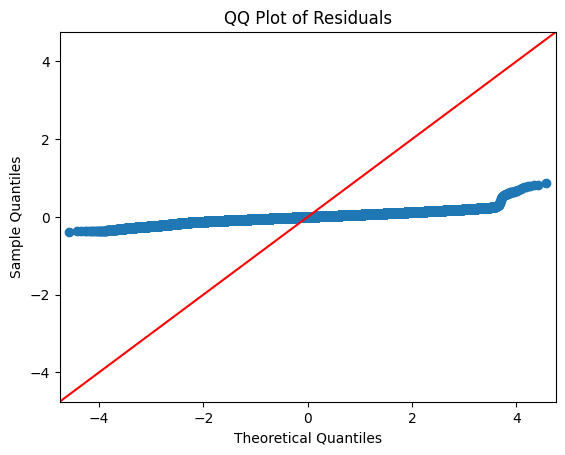

In [34]:
sm.qqplot(model.resid, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

### Residuals Vs. Fitted

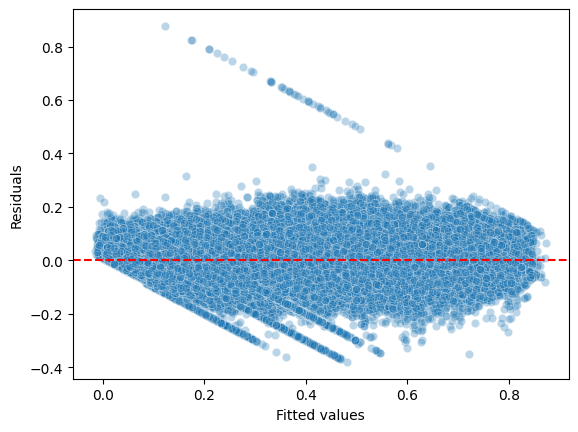

In [35]:
sns.scatterplot(x=model.fittedvalues, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

### 3. Multicollinearity

In [36]:
X_no_const = X.drop(columns=['const'])
vif_data = pd.DataFrame()
vif_data['feature'] = X_no_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=False))

                   feature       VIF
0                num_lanes  4.799534
1                curvature  3.942240
6   num_reported_accidents  2.747254
4                  holiday  1.969374
3              public_road  1.951795
2       road_signs_present  1.926016
16      speed_limit_cat_45  1.922397
5            school_season  1.916496
9             lighting_dim  1.915621
11           weather_foggy  1.914519
14     time_of_day_morning  1.896723
13     time_of_day_evening  1.892818
8          road_type_urban  1.887187
7          road_type_rural  1.883264
15      speed_limit_cat_35  1.877191
12           weather_rainy  1.804296
17      speed_limit_cat_60  1.796086
10          lighting_night  1.791352
18      speed_limit_cat_70  1.699401


### 4. Linear Relationship of Predictors with Outcome

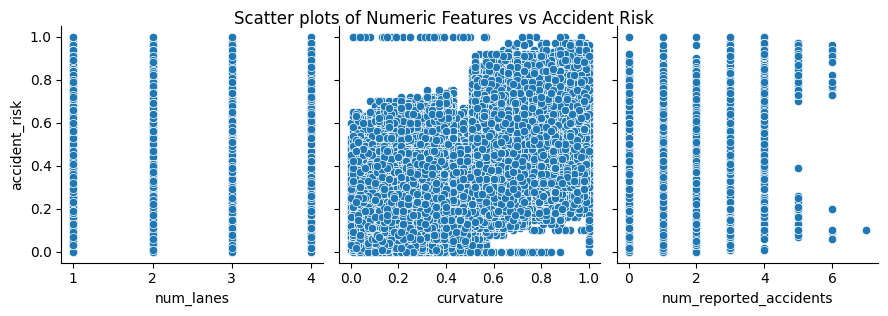

In [37]:
numeric_features = ['num_lanes', 'curvature', 'num_reported_accidents']

# Combine X and y for plotting
plot_df = pd.concat([X[numeric_features], y.reset_index(drop=True)], axis=1)

sns.pairplot(plot_df, x_vars=numeric_features, y_vars='accident_risk', height=3, aspect=1)
plt.suptitle("Scatter plots of Numeric Features vs Accident Risk", y=1.02)
plt.show()

### 5. Independece of Observations

In [38]:
dw = durbin_watson(model.resid)
print("Durbin-Watson statistic:", dw)

Durbin-Watson statistic: 2.002012454600519


### Compute RMSE

In [39]:
# Predict on validation subset
y_val_pred = model.predict(X_val)

# Compute RMSE on validation set
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("RMSE on validation set:", rmse_val)

RMSE on validation set: 0.0614194850941154


In [40]:
y_val_pred.shape

(103551,)

### Get Predictions for Test Dataset

In [41]:
test.head()

,id,road_type,num_lanes,curvature,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,speed_limit_cat
0,517754,highway,2,0.34,night,clear,True,True,afternoon,True,True,1,45
1,517755,urban,3,0.04,dim,foggy,True,False,afternoon,True,False,0,45
2,517756,urban,2,0.59,dim,clear,True,False,afternoon,True,True,1,35
3,517757,rural,4,0.95,daylight,rainy,False,False,afternoon,False,False,2,35
4,517758,highway,2,0.86,daylight,clear,True,False,evening,False,True,3,35


In [42]:
test_ids = test['id'].copy()

# Apply same preprocessing to test set
test[boolean_features] = test[boolean_features].astype(int)

# One-hot encode categorical variables (same as training)
test = pd.get_dummies(test, columns=categorical_features, drop_first=True)

# Align columns with training data (so they match exactly)
test = test.reindex(columns=X_train.columns, fill_value=0)

# Standardize numeric features using the same scaler
test[numeric_features] = scaler.transform(test[numeric_features])

# Predict on test set
y_test_pred = model.predict(test)
y_test_pred.head()


0    0.137995
1   -0.069185
2     0.03014
3    0.258357
4    0.148096
dtype: object

In [43]:
y_test_pred.shape

(172585,)

In [44]:
test.shape

(172585, 20)

In [45]:
test.head()

,const,num_lanes,curvature,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,speed_limit_cat_35,speed_limit_cat_45,speed_limit_cat_60,speed_limit_cat_70
0,0,-0.440100,-0.546026,1,1,1,1,-0.209658,False,False,False,True,False,False,False,False,False,True,False,False
1,0,0.452165,-1.647388,1,0,1,0,-1.325563,False,True,True,False,True,False,False,False,False,True,False,False
2,0,-0.440100,0.371776,1,0,1,1,-0.209658,False,True,True,False,False,False,False,False,True,False,False,False
3,0,1.344431,1.693410,0,0,0,0,0.906247,True,False,False,False,False,True,False,False,True,False,False,False
4,0,-0.440100,1.363002,1,0,0,1,2.022153,False,False,False,False,False,False,True,False,True,False,False,False


In [48]:
submission = pd.DataFrame({
    'id': test_ids,
    'accident_risk_pred': y_test_pred
})

submission.to_csv("../Submissions/Linear_Regression_1.csv", index=False)
